# Hafta 7 — Eliptik KDD'ler ve Doğrusal Olmayan Korunum Yasaları

> **Bilim İnsanları ve Mühendisler için Diferansiyel Denklemler**  
> *Laplace, SOR, iki seviyeli çoklu ızgara ve şok yakalamalı Burgers denklemi.*

---

## Öğrenme Hedefleri

1. **2B Poisson/Laplace denklemini** 5 noktalı şablonla ayrıklaştırmak
2. **Jacobi**, **Gauss-Seidel** ve **SOR** yinelemeli çözücülerini uygulamak
3. Sıfırdan **2 seviyeli çoklu ızgara** (V-döngüsü) kurmak
4. **Burgers denklemini** kanonik doğrusal olmayan korunum yasası olarak anlamak
5. **Rüzgar yukarı (upwind)**, **Lax-Wendroff** uygulamak ve entropi koşullarıyla şokları tespit etmek
6. Şok oluşumunu ve seyrelme dalgalarını görselleştirmek


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'serif',
})

---

## 1. 2B Laplace/Poisson Denklemi

$$-\nabla^2 u = -u_{xx} - u_{yy} = f(x, y) \quad \text{üzerinde } \Omega = (0,1)^2$$

Dirichlet sınır koşulları ile. **5 noktalı sonlu fark şablonu** (merkezi farklar $O(h^2)$) şunu verir:

$$\frac{-u_{i-1,j} - u_{i+1,j} - u_{i,j-1} - u_{i,j+1} + 4u_{i,j}}{h^2} = f_{ij}$$

Bu, $N^2$ bilinmeyenli seyrek bir doğrusal sistem $Au = b$ üretir ($N\times N$ iç ızgara için).

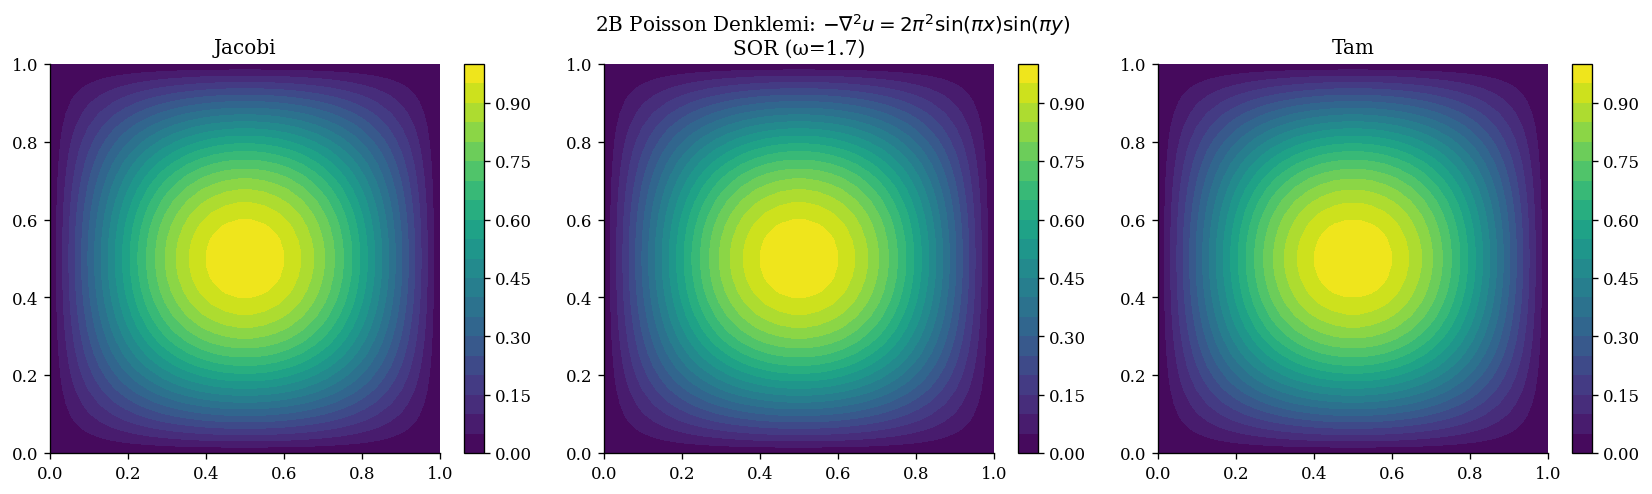

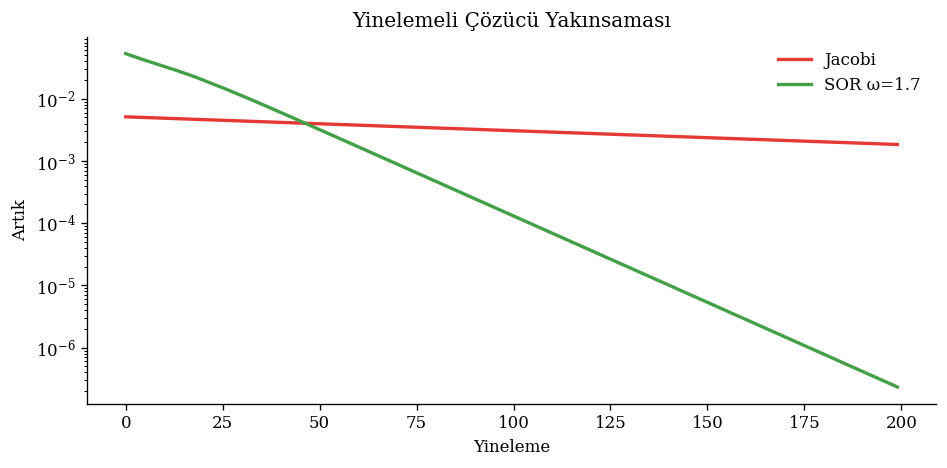

In [2]:
def jacobi_yineleme(u, f, h, n_yineleme=1000, tol=1e-8):
    """Poisson denklemi için Jacobi yinelemeli çözücü."""
    u = u.copy()
    artiklar = []
    for _ in range(n_yineleme):
        u_yeni = u.copy()
        u_yeni[1:-1, 1:-1] = 0.25 * (
            u[:-2, 1:-1] + u[2:, 1:-1] +
            u[1:-1, :-2] + u[1:-1, 2:] +
            h**2 * f[1:-1, 1:-1]
        )
        artik = np.max(np.abs(u_yeni - u))
        artiklar.append(artik)
        u = u_yeni
        if artik < tol:
            break
    return u, artiklar


def sor_yineleme_basit(u, f, h, omega=1.5, n_yineleme=1000, tol=1e-8):
    """
    Ardışık Aşırı Gevşetme (SOR).
    N x N ızgarada Laplace için optimal omega: omega = 2/(1+sin(pi/(N+1)))
    """
    u = u.copy()
    artiklar = []
    for _ in range(n_yineleme):
        u_eski = u.copy()
        for i in range(1, u.shape[0]-1):
            for j in range(1, u.shape[1]-1):
                u_gs = 0.25 * (u[i-1,j] + u[i+1,j] +
                               u[i,j-1] + u[i,j+1] +
                               h**2 * f[i,j])
                u[i,j] = omega * u_gs + (1 - omega) * u[i,j]
        artik = np.max(np.abs(u - u_eski))
        artiklar.append(artik)
        if artik < tol:
            break
    return u, artiklar


# --- Poisson denklemi: -Laplace(u) = f = 2pi^2*sin(pi*x)*sin(pi*y) ---
# Tam çözüm: u(x,y) = sin(pi*x)*sin(pi*y)
N = 30
h = 1.0 / (N+1)
x_1b = np.linspace(0, 1, N+2)
X, Y = np.meshgrid(x_1b, x_1b)
f = 2 * np.pi**2 * np.sin(np.pi*X) * np.sin(np.pi*Y)
u_tam = np.sin(np.pi*X) * np.sin(np.pi*Y)
u_baslangic = np.zeros((N+2, N+2))

u_jac, artik_jac = jacobi_yineleme(u_baslangic, f, h, n_yineleme=3000)
u_sor, artik_sor = sor_yineleme_basit(u_baslangic, f, h, omega=1.7, n_yineleme=3000)

fig, eksenler = plt.subplots(1, 3, figsize=(14, 4))
for ax, u, baslik in zip(eksenler, [u_jac, u_sor, u_tam],
                         ['Jacobi', 'SOR (ω=1.7)', 'Tam']):
    im = ax.contourf(X, Y, u, 20, cmap='viridis')
    plt.colorbar(im, ax=ax)
    ax.set_title(baslik); ax.set_aspect('equal')

plt.suptitle('2B Poisson Denklemi: $-\\nabla^2 u = 2\\pi^2\\sin(\\pi x)\\sin(\\pi y)$')
plt.tight_layout(); plt.show()

# Yakınsama karşılaştırması
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(artik_jac[:200], label='Jacobi', color='#E53935', lw=2)
ax.semilogy(artik_sor[:200], label='SOR ω=1.7', color='#43A047', lw=2)
ax.set_xlabel('Yineleme'); ax.set_ylabel('Artık')
ax.set_title('Yinelemeli Çözücü Yakınsaması')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

---

## 2. Yinelemeli Çözücüler — Jacobi, Gauss-Seidel, SOR

Ayrıklaştırılmış Poisson denklemi $A\mathbf{u} = \mathbf{f}$ (seyrek, köşegen baskın) için üç klasik yineleme:

| Yöntem | Güncelleme | Yakınsama oranı |
|--------|--------|------------------|
| **Jacobi** | $u^{(k+1)}_i = \frac{1}{a_{ii}}(b_i - \sum_{j\neq i} a_{ij}u^{(k)}_j)$ | $\rho = \cos(\pi h)$ |
| **Gauss-Seidel** | Güncellenen değerleri hemen kullan | $\rho^2_{\text{Jacobi}}$ |
| **SOR** $(\omega)$ | $u^{(k+1)} = \omega u^{\text{GS}} + (1-\omega)u^{(k)}$ | Optimal $\omega^* = \frac{2}{1+\sin(\pi h)}$ |

**Spektral yarıçap** $\rho < 1$ yakınsamayı garanti eder; $\omega^*$ ile SOR, $\rho \approx 1 - \pi h$ elde eder; bu da Jacobi'den ($\rho \approx 1 - \frac{\pi^2 h^2}{2}$) çarpıcı şekilde daha hızlıdır.

**Artık:** $r^{(k)} = \|b - Au^{(k)}\|_\infty$ — $r < \text{tol}$ olduğunda yakınsama ilan edilir.

Optimal SOR omega: 1.8107
Jacobi   1864 yinelemede yakınsadı
G-Seidel  996 yinelemede yakınsadı
SOR        86 yinelemede yakınsadı
SOR'un tam çözüme karşı hatası: 4.63e-05


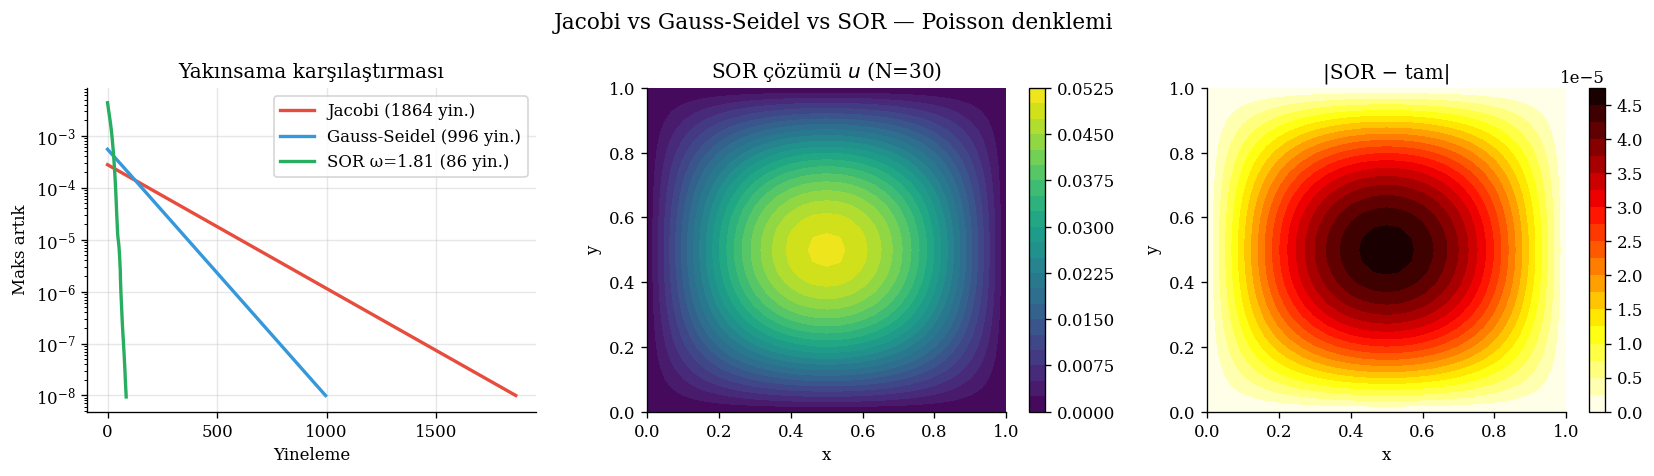

In [3]:
def gauss_seidel(u, f, h, n_yineleme=2000, tol=1e-8):
    """
    (0,1)² üzerinde sınırda u=0 ile -∇²u = f için Gauss-Seidel yinelemesi.
    Her iç noktayı en son değerleri kullanarak hemen günceller.
    """
    u = u.copy()
    h2 = h * h
    artiklar = []
    for k in range(n_yineleme):
        u_eski = u.copy()
        for i in range(1, u.shape[0]-1):
            for j in range(1, u.shape[1]-1):
                u[i,j] = 0.25*(u[i+1,j] + u[i-1,j] +
                                u[i,j+1] + u[i,j-1] + h2*f[i,j])
        artik = np.max(np.abs(u - u_eski))
        artiklar.append(artik)
        if artik < tol:
            break
    return u, artiklar


def sor_yineleme(u, f, h, omega, n_yineleme=2000, tol=1e-8):
    """
    -∇²u = f için SOR (Ardışık Aşırı Gevşetme).
    omega=1 Gauss-Seidel'i verir; optimal omega = 2/(1+sin(pi*h)).
    """
    u = u.copy()
    h2 = h * h
    artiklar = []
    for k in range(n_yineleme):
        u_eski = u.copy()
        for i in range(1, u.shape[0]-1):
            for j in range(1, u.shape[1]-1):
                u_gs = 0.25*(u[i+1,j] + u[i-1,j] +
                             u[i,j+1] + u[i,j-1] + h2*f[i,j])
                u[i,j] = omega*u_gs + (1-omega)*u[i,j]
        artik = np.max(np.abs(u - u_eski))
        artiklar.append(artik)
        if artik < tol:
            break
    return u, artiklar


# ── Kurulum: N=30 ızgara, f = sin(πx)sin(πy) ──────────
N = 30
h_deg = 1.0 / N
x_g = np.linspace(0, 1, N+1)
y_g = np.linspace(0, 1, N+1)
XX, YY = np.meshgrid(x_g, y_g)

# f = sin(πx)sin(πy), tam: u = sin(πx)sin(πy)/(2π²)
f_sag2 = np.sin(np.pi*XX) * np.sin(np.pi*YY)
u_tam2 = f_sag2 / (2 * np.pi**2)

u0 = np.zeros((N+1, N+1))   # başlangıç tahmini, SK'lar=0

omega_opt = 2.0 / (1.0 + np.sin(np.pi * h_deg))

# Adil karşılaştırma için satır içi Jacobi
def jacobi_satirici(u, f, h, n_yineleme=2000, tol=1e-8):
    u = u.copy(); h2 = h*h; artiklar = []
    for k in range(n_yineleme):
        u_yeni = u.copy()
        u_yeni[1:-1,1:-1] = 0.25*(u[2:,1:-1]+u[:-2,1:-1]+u[1:-1,2:]+u[1:-1,:-2]+h2*f[1:-1,1:-1])
        artik = np.max(np.abs(u_yeni - u)); artiklar.append(artik); u = u_yeni
        if artik < tol: break
    return u, artiklar

u_jac, artik_jac = jacobi_satirici(u0, f_sag2, h_deg)
u_gs,  artik_gs  = gauss_seidel(u0, f_sag2, h_deg)
u_sor, artik_sor = sor_yineleme(u0, f_sag2, h_deg, omega=omega_opt)

print(f'Optimal SOR omega: {omega_opt:.4f}')
print(f'Jacobi   {len(artik_jac):4d} yinelemede yakınsadı')
print(f'G-Seidel {len(artik_gs):4d} yinelemede yakınsadı')
print(f'SOR      {len(artik_sor):4d} yinelemede yakınsadı')
print(f'SOR\'un tam çözüme karşı hatası: {np.max(np.abs(u_sor - u_tam2)):.2e}')

fig, eksenler = plt.subplots(1, 3, figsize=(14, 4))

# Yakınsama geçmişleri
ax = eksenler[0]
ax.semilogy(artik_jac, lw=2, color='#e74c3c', label=f'Jacobi ({len(artik_jac)} yin.)')
ax.semilogy(artik_gs,  lw=2, color='#3498db', label=f'Gauss-Seidel ({len(artik_gs)} yin.)')
ax.semilogy(artik_sor, lw=2, color='#27ae60', label=f'SOR ω={omega_opt:.2f} ({len(artik_sor)} yin.)')
ax.set_xlabel('Yineleme'); ax.set_ylabel('Maks artık')
ax.set_title('Yakınsama karşılaştırması'); ax.legend(); ax.grid(alpha=0.3)

# SOR çözümü
ax = eksenler[1]
im = ax.contourf(XX, YY, u_sor, 20, cmap='viridis')
plt.colorbar(im, ax=ax)
ax.set_title(f'SOR çözümü $u$ (N={N})')
ax.set_xlabel('x'); ax.set_ylabel('y')

# Tam çözüme karşı hata
ax = eksenler[2]
im2 = ax.contourf(XX, YY, np.abs(u_sor - u_tam2), 20, cmap='hot_r')
plt.colorbar(im2, ax=ax)
ax.set_title('|SOR − tam|')
ax.set_xlabel('x'); ax.set_ylabel('y')

fig.suptitle('Jacobi vs Gauss-Seidel vs SOR — Poisson denklemi', fontsize=13)
plt.tight_layout()
plt.show()

---

## 3. Burgers Denklemi — Kanonik Doğrusal Olmayan Korunum Yasası

**Viskozitesiz Burgers denklemi**:

$$\frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} = 0 \quad \Leftrightarrow \quad \frac{\partial u}{\partial t} + \frac{\partial}{\partial x}\left(\frac{u^2}{2}\right) = 0$$

Karakteristikler $c = u$ hızıyla hareket eder; bu yüzden hızlı dalgalar yavaşları geçer → $T_s = -1/\min_x u_0'(x)$ zamanında **şok oluşumu**.

**Viskozlu Burgers denklemi** $\nu u_{xx}$ ekler:

$$u_t + u\,u_x = \nu\,u_{xx}$$

Bu, Hopf-Cole analitik çözümüne sahiptir ve şoku düzleştirir.

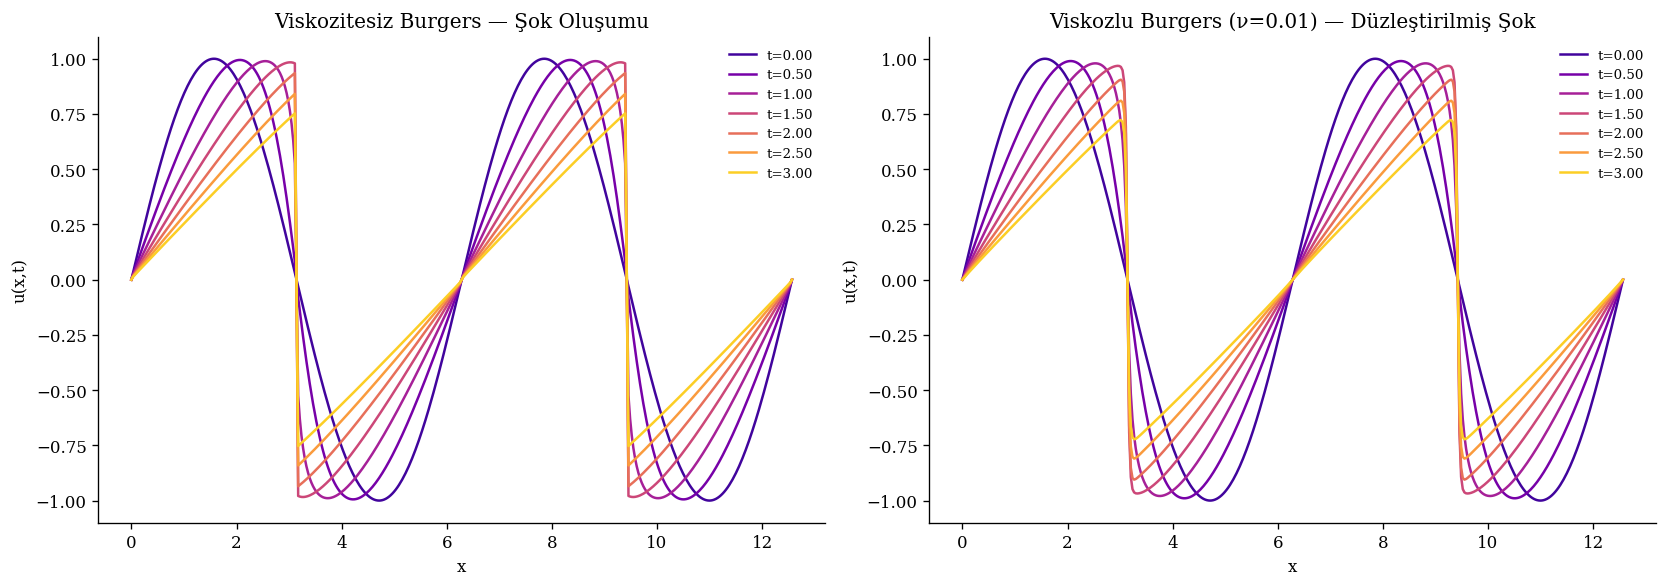

In [4]:
def burgers_upwind(u0, dx, dt, T, nu=0.0):
    """
    Viskozitesiz Burgers için Godunov rüzgar yukarı + Lax-Wendroff düzeltmesi.
    nu: viskozite katsayısı (viskozitesiz için 0 ayarla)
    """
    u = u0.copy()
    N_t = int(T / dt)
    anlik_goruntuler = [(0, u.copy())]

    for n in range(N_t):
        # f(u) = u^2/2'nin korunum formu için Godunov akısı
        u_orta = 0.5 * (u[:-1] + u[1:])   # Lax-Friedrichs ortalaması
        F = 0.5 * u**2

        # Rüzgar yukarı: u'nun işaretine göre F kullan
        F_yari = np.where(u_orta > 0, F[:-1], F[1:])  # sol/sağ akı

        u_yeni = u.copy()
        u_yeni[1:-1] -= dt/dx * (F_yari[1:] - F_yari[:-1])

        if nu > 0:
            u_yeni[1:-1] += nu * dt / dx**2 * (u[2:] - 2*u[1:-1] + u[:-2])

        u = u_yeni.copy()
        if (n+1) % max(1, N_t // 6) == 0:
            anlik_goruntuler.append(((n+1)*dt, u.copy()))

    return anlik_goruntuler


L_bg = 4 * np.pi
Nx_bg = 400
dx_bg = L_bg / Nx_bg
dt_bg = 0.3 * dx_bg   # CFL
x_bg = np.linspace(0, L_bg, Nx_bg+1)

# BK: pürüzsüz sinüzoidal, şok T_s = 1'de oluşur
u0_bg = np.sin(x_bg)

anlik_visz = burgers_upwind(u0_bg.copy(), dx_bg, dt_bg, T=3.0, nu=0.0)
anlik_vis = burgers_upwind(u0_bg.copy(), dx_bg, dt_bg, T=3.0, nu=0.01)

fig, eksenler = plt.subplots(1, 2, figsize=(14, 5))
renkler = cm.plasma(np.linspace(0.1, 0.9, len(anlik_visz)))

for (t_deg, u_anlik), c in zip(anlik_visz, renkler):
    eksenler[0].plot(x_bg, u_anlik, color=c, lw=1.5, label=f't={t_deg:.2f}')
eksenler[0].set_title('Viskozitesiz Burgers — Şok Oluşumu')
eksenler[0].legend(frameon=False, fontsize=8)

for (t_deg, u_anlik), c in zip(anlik_vis, renkler):
    eksenler[1].plot(x_bg, u_anlik, color=c, lw=1.5, label=f't={t_deg:.2f}')
eksenler[1].set_title('Viskozlu Burgers (ν=0.01) — Düzleştirilmiş Şok')
eksenler[1].legend(frameon=False, fontsize=8)

for ax in eksenler:
    ax.set_xlabel('x'); ax.set_ylabel('u(x,t)')
plt.tight_layout(); plt.show()

---

## 4. Alıştırmalar

1. **(SOR optimal omega)** $N\times N$ Poisson problemi için optimal SOR gevşetme parametresi $\omega^* = 2/(1 + \sin(\pi/(N+1)))$'dir. Bunu $N = 20$ için yakınsama oranını $\omega$'ya karşı çizerek sayısal doğrulayın.

2. **(Çoklu ızgara)** 1B Poisson denklemi için 2 seviyeli V-döngüsü çoklu ızgara uygulayın. Düzleştirici olarak Gauss-Seidel, uzatma için parçalı doğrusal interpolasyon ve tam ağırlıklı kısıtlama kullanın. Yakınsamayı düz Gauss-Seidel ile karşılaştırın.

3. **(Karakteristikler yöntemi)** Viskozitesiz Burgers denklemini $x < 0$ için $u_0(x) = 1$ ve $x > 0$ için $u_0(x) = 0$ BK'sı (şok başlangıç verisi) ile çözün. Şok hızını Rankine-Hugoniot koşulundan bulun ve sayısal çözümle karşılaştırın.

4. **(Lax-Wendroff)** Burgers için Lax-Wendroff şemasını uygulayın ve rüzgar yukarı ile karşılaştırın. Lax-Wendroff'un pürüzsüz bölgelerde 2. mertebe doğru olduğunu ama şokların yakınında sahte salınımlar ürettiğini gösterin.

5. **(Entropi koşulu)** $x < 0$ için $u_0 = 0$ ve $x > 0$ için $u_0 = 1$ BK'lı viskozitesiz Burgers denkleminin iki matematiksel çözümü vardır. Hangisi entropi koşulunu (Lax koşulu) sağlar? Her ikisini de uygulayın ve sayısal şemanın doğal olarak hangisini seçtiğini belirleyin.
